<a href="https://colab.research.google.com/github/pri-2711/qiskit_codes/blob/main/Qiskit_code_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install qiskit_ibm_provider
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 119.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2c9e9e30418e09f4e14b0420776f4a6673ef35f6dedb435356d1fe9261d918dc
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178be

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
import numpy as np

Bernstein-Vazirai Problem (with Deustch-Jozsa Algorithm)

In [4]:
def bv_query(s):
  # making input function : Query Gate
  qc=QuantumCircuit(len(s)+1)
  for index, bit in enumerate(reversed(s)):
    if bit=="1":
      qc.cx(index,len(s))
  return qc


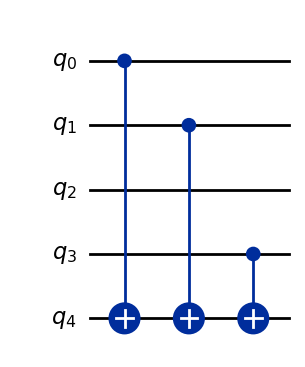

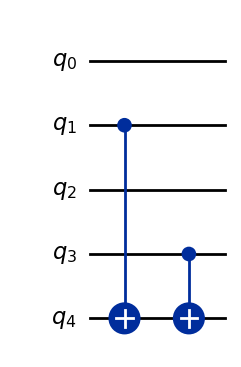

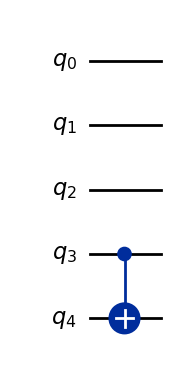

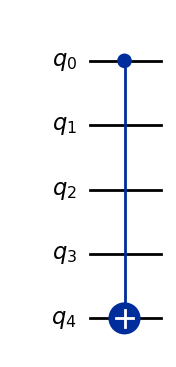

In [5]:
display(bv_query("1011").draw("mpl"))
display(bv_query("1010").draw("mpl"))
display(bv_query("1000").draw("mpl"))
display(bv_query("0001").draw("mpl"))

In [6]:
# from Deutsch-Jozsa algorithm
def compile_circuit(function: QuantumCircuit):
  n=function.num_qubits-1
  qc=QuantumCircuit(n+1,n)
  qc.x(n)
  qc.h(range(n+1)) # H gate to all Qubits
  qc.compose(function,inplace=True) # including Unitary funciton
  qc.barrier()
  qc.h(range(n)) # H to all qubits except Ancilla qubit
  qc.measure(range(n),range(n)) # collapsing system thru Measurement
  return qc

In [7]:
def bv_algorithm(function: QuantumCircuit):
  qc=compile_circuit(function)
  result=AerSimulator().run(qc,shots=1,memory=True).result()
  return result.get_memory()[0]


In [8]:
display(bv_algorithm(bv_query("1011")))
display(bv_algorithm(bv_query("1010")))
display(bv_algorithm(bv_query("1000")))
display(bv_algorithm(bv_query("0001")))

'1011'

'1010'

'1000'

'0001'